# Self Driving Car using Udacity Simlator

In [1]:
# librarries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
%matplotlib inline
import cv2
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv('driving_log.csv')
df.columns=['center','left','right','steering_angle','throtle','brake','speed']

df.head()

,center,left,right,steering_angle,throtle,brake,speed
0,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.0,0.0,0.0,4.933050e-06
1,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.0,0.0,0.0,3.807648e-06
2,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.0,0.0,0.0,4.499547e-06
3,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.0,0.0,0.0,4.735151e-06
4,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.0,0.0,0.0,4.221761e-07


In [3]:
print("shape of data " + " " +str(df.shape))

shape of data  (36011, 7)


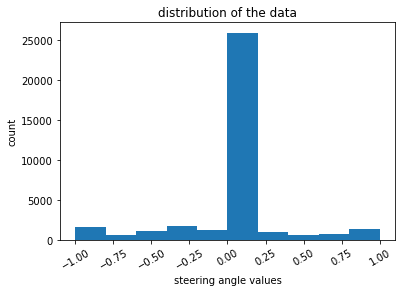

In [3]:
plt.hist(df.steering_angle)
plt.title("distribution of the data")
plt.xlabel("steering angle values")
plt.ylabel('count')
plt.xticks(rotation=30)
plt.show()

In [4]:
drop_index=df[df.steering_angle==0].index
drop_indices = np.random.choice(drop_index, 23500, replace=False)
df_subset = df.drop(drop_indices)
df_subset.shape
df_subset.head()

,center,left,right,steering_angle,throtle,brake,speed
10,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.00,0.0,0.0,0.000016
20,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.15,1.0,0.0,3.249828
21,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.35,1.0,0.0,4.177734
22,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.50,1.0,0.0,4.858728
23,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.70,1.0,0.0,5.742650


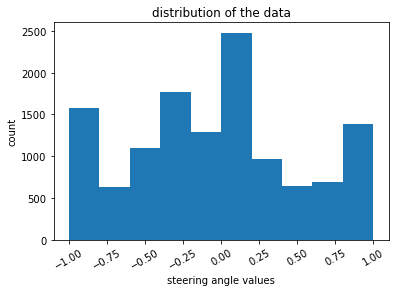

(12517, 7)


In [5]:
plt.hist(df_subset.steering_angle)
plt.title("distribution of the data")
plt.xlabel("steering angle values")
plt.ylabel('count')
plt.xticks(rotation=30)
plt.show()
print(df_subset.shape)

In [6]:
df_subset=df_subset.reset_index(drop=True)
df_subset.head()

,center,left,right,steering_angle,throtle,brake,speed
0,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,0.00,0.0,0.0,0.000016
1,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.15,1.0,0.0,3.249828
2,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.35,1.0,0.0,4.177734
3,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.50,1.0,0.0,4.858728
4,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,C:\Users\vishweshwar\Documents\aiselfenabled\I...,-0.70,1.0,0.0,5.742650


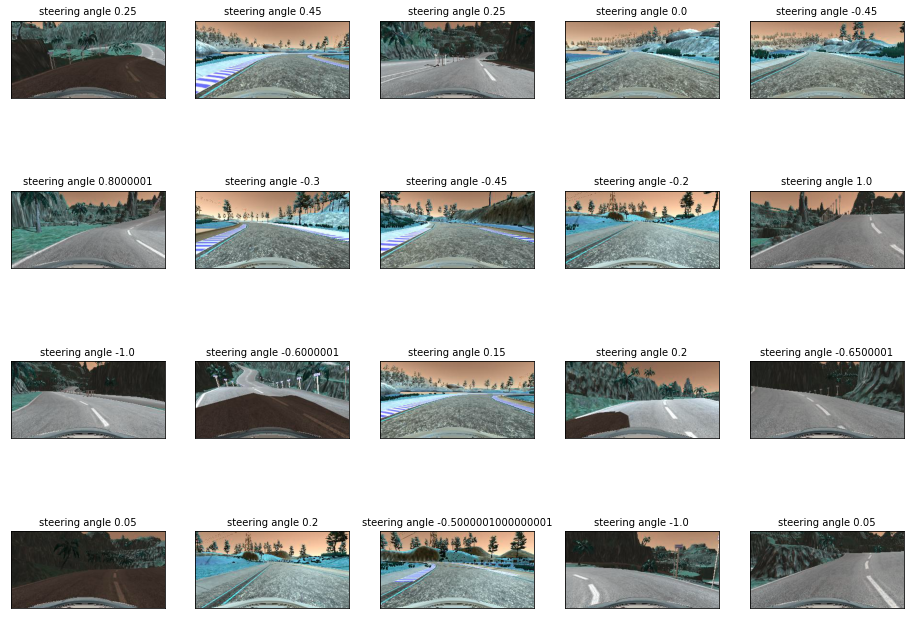

In [7]:
plt.figure(figsize=(16,12))
for i in range(20):
    rdm_no=random.randint(0,len(df_subset))
    plt.subplot(4,5,i+1,)
    pic=cv2.imread(df_subset.center[rdm_no])
    plt.imshow(pic)
    plt.title(label="steering angle"+" "+str(df_subset.steering_angle[rdm_no]),size=10,color="black")
    plt.xticks([])
    plt.yticks([])

In [8]:
for i in range(len(df_subset)):
    img=cv2.imread(df_subset.center[i])
    crop=img[60:,:]
    crop= cv2.GaussianBlur(crop,  (3, 3), 0)
    crop=cv2.cvtColor(crop,cv2.COLOR_RGB2GRAY)
    crop=cv2.resize(crop,(200,66))
    cv2.imwrite(df_subset.center[i],crop)

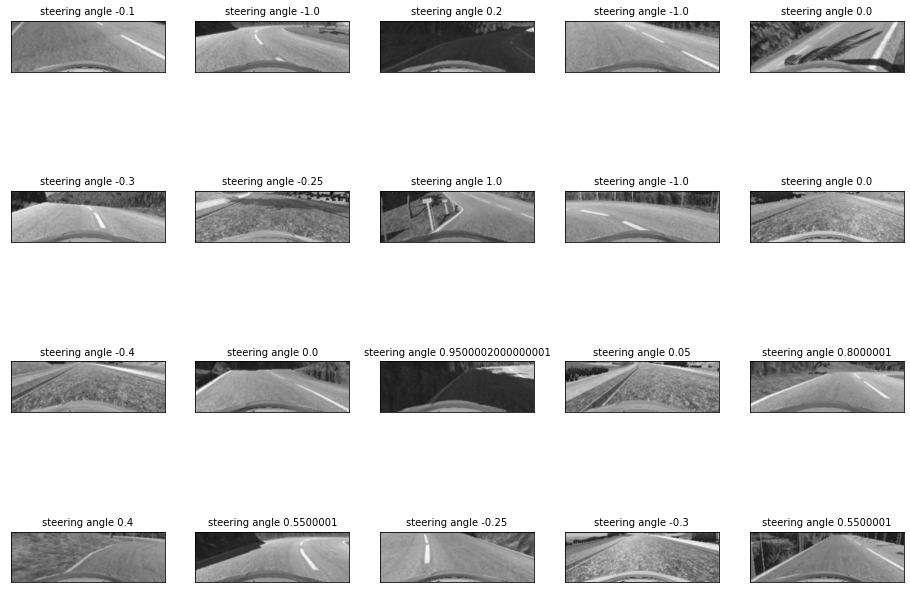

In [9]:
plt.figure(figsize=(16,12))
for i in range(20):
    rdm_no=random.randint(0,len(df_subset))
    plt.subplot(4,5,i+1,)
    pic=cv2.imread(df_subset.center[rdm_no])
    plt.imshow(pic)
    plt.title(label="steering angle"+" "+str(df_subset.steering_angle[rdm_no]),size=10,color="black")
    plt.xticks([])
    plt.yticks([])

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train,test=train_test_split(df_subset,test_size=.20,random_state=2001)

train_datagen = ImageDataGenerator(rescale = 1./255, horizontal_flip = False,
                                   fill_mode = "nearest", zoom_range = 0.2,
                                   width_shift_range = 0.2, height_shift_range=0.2,)
image_dir=r"C:\Users\vishweshwar\Documents\aiselfenabled\IMG"
batch_size=32
train_data= train_datagen.flow_from_dataframe(dataframe=train, directory=image_dir, 
                                              x_col="center", y_col="steering_angle", 
                                              class_mode="raw", target_size=(200, 66), 
                                              batch_size=batch_size)
test_datagen = ImageDataGenerator(rescale = 1./255, horizontal_flip = False,
                                   fill_mode = "nearest", zoom_range = 0.2,
                                   width_shift_range = 0.2, height_shift_range=0.2,)

test_data=test_datagen.flow_from_dataframe(dataframe=test, directory=image_dir, 
                                              x_col="center", y_col="steering_angle", 
                                              class_mode="raw", target_size=(66, 200), 
                                              batch_size=batch_size)
del df
del df_subset

Found 10013 validated image filenames.
Found 2504 validated image filenames.


In [11]:
from tensorflow.keras.layers import Convolution2D,Flatten,BatchNormalization,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import elu
from tensorflow.keras.losses import mse
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import mean_absolute_error



In [12]:
model=Sequential()
model.add(Convolution2D(24, (5, 5), (2, 2), input_shape=(66, 200, 1), activation='elu'))
model.add(Convolution2D(36, (5, 5), (2, 2), activation='elu'))
model.add(Convolution2D(48, (5, 5), (2, 2), activation='elu'))
model.add(Convolution2D(64, (3, 3), activation='elu'))
model.add(Convolution2D(64, (3, 3), activation='elu'))
model.add(Flatten())
model.add(Dense(100, activation = elu))
model.add(Dropout(0.3))
model.add(Dense(50, activation = elu))
model.add(Dropout(0.2))
model.add(Dense(10, activation = elu))
model.add(Dense(1))
model.compile(Adam(learning_rate=0.0001),loss=mse,metrics=mean_absolute_error)
  

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 31, 98, 24)        624       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 47, 36)        21636     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 5, 22, 48)         43248     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 3, 20, 64)         27712     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 1, 18, 64)         36928     
_________________________________________________________________
flatten (Flatten)            (None, 1152)              0         
_________________________________________________________________
dense (Dense)                (None, 100)               1

In [14]:
import os
callback=[EarlyStopping(monitor='val_loss',min_delta=0.001, patience=4,verbose=1),
         ModelCheckpoint('model.h5',monitor='val_loss',save_best_only=True,verbose=1),
         ReduceLROnPlateau(monitor='val_loss',factor=0.5,min_delta=0.001,verbose=1,patience=2)]


# gpu configuration

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'True'
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)




history = model.fit(train_data,
                    epochs=30,
                    validation_data=test_data,
                
                   callbacks=callback)


Epoch 1/30
313/313 [==============================] - 81s 235ms/step - loss: 0.2812 - mean_absolute_error: 0.4210 - val_loss: 0.2456 - val_mean_absolute_error: 0.3922

Epoch 00001: val_loss improved from inf to 0.24561, saving model to model.h5
Epoch 2/30
313/313 [==============================] - 36s 113ms/step - loss: 0.2538 - mean_absolute_error: 0.3971 - val_loss: 0.2395 - val_mean_absolute_error: 0.3864

Epoch 00002: val_loss improved from 0.24561 to 0.23946, saving model to model.h5
Epoch 3/30
313/313 [==============================] - 36s 115ms/step - loss: 0.2466 - mean_absolute_error: 0.3899 - val_loss: 0.2549 - val_mean_absolute_error: 0.3965

Epoch 00003: val_loss did not improve from 0.23946
Epoch 4/30
313/313 [==============================] - 36s 115ms/step - loss: 0.2448 - mean_absolute_error: 0.3884 - val_loss: 0.2229 - val_mean_absolute_error: 0.3677

Epoch 00004: val_loss improved from 0.23946 to 0.22289, saving model to model.h5
Epoch 5/30
313/313 [==================

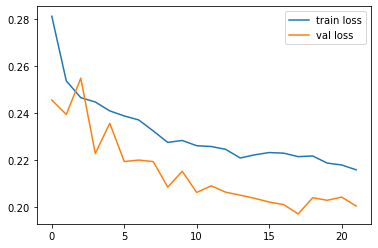

In [15]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()


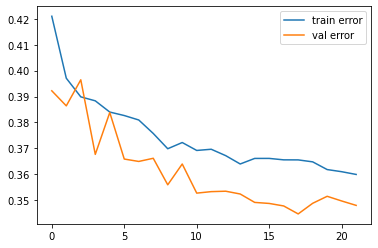

In [16]:
plt.plot(history.history['mean_absolute_error'], label='train error')
plt.plot(history.history['val_mean_absolute_error'], label='val error')
plt.legend()
plt.show()

## ----------------------------------------------- THE END---------------------------------------------- 